In [4]:
# This notebook applies the following basic Machine Learning models:
# Random Forest, XGBoost
###

# 0. Preparation
###
# Importing libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import xgboost as xgb

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, f1_score
from sklearn import linear_model, preprocessing
from sklearn.model_selection import train_test_split
from sklearn import svm, neighbors, ensemble
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [ ]:
# Mounting GoogleDrive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Reading data file from GoogleDrive
df = pd.read_pickle("/content/drive/My Drive/Data Science/Team Project X-Rays/Dataframes/df_basic_1.4.pkl")
df.head()

# Define data name
df_name = "Baseline 1.4"

# Define random subsample for testing code
#df = df.sample(500)


In [ ]:
# Explore Data
###

# Check data type is DataFrame
print(type(df))

# Show dimensions
print(df.shape)

# Show labels
print(df.Case.value_counts())

# Check distributions after normalisation
df.describe()



<class 'pandas.core.frame.DataFrame'>
(21105, 4098)
Case
Normal             10191
Lung_Opacity        6012
COVID               3564
Viral Pneumonia     1338
Name: count, dtype: int64


,PX_1,PX_2,PX_3,PX_4,PX_5,PX_6,PX_7,PX_8,PX_9,PX_10,...,PX_4087,PX_4088,PX_4089,PX_4090,PX_4091,PX_4092,PX_4093,PX_4094,PX_4095,PX_4096
count,21105.000000,21105.000000,21105.000000,21105.000000,21105.000000,21105.000000,21105.000000,21105.000000,21105.000000,21105.000000,...,21105.000000,21105.000000,21105.000000,21105.000000,21105.000000,21105.000000,21105.000000,21105.000000,21105.000000,21105.000000
mean,42.727790,33.668657,33.446956,34.641838,35.782516,36.980858,37.975503,38.742099,39.627955,40.497891,...,148.859038,138.535134,126.862213,114.337835,100.699550,87.301398,75.467851,65.328879,58.607202,60.391803
std,61.404887,53.275717,52.336637,52.416730,52.688332,53.027111,53.557134,54.049191,54.539456,55.109691,...,69.108036,72.401729,75.401226,77.495805,78.369439,78.194965,76.628920,74.093986,71.465077,72.464377
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,1.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,116.000000,94.000000,63.000000,32.000000,16.000000,9.000000,6.000000,3.000000,2.000000,2.000000
50%,12.000000,9.000000,8.000000,9.000000,10.000000,10.000000,11.000000,11.000000,12.000000,12.000000,...,167.000000,157.000000,144.000000,128.000000,104.000000,73.000000,44.000000,26.000000,20.000000,23.000000
75%,58.000000,39.000000,40.000000,45.000000,50.000000,55.000000,58.000000,60.000000,63.000000,64.000000,...,200.000000,194.000000,188.000000,180.000000,170.000000,157.000000,141.000000,122.000000,105.000000,107.000000
max,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,...,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000


In [ ]:
# Check missing values
print(df.info())

print("Missing vars in columns:\n", df.isna().sum())
print("Number of total missing vars:", df.isna().sum().sum())
print("Number of total missing vars (% of all obs):", (df.isna().sum().sum())/(df.shape[0]*df.shape[1]))

# No missing vars. We can continue the ML modelling.

<class 'pandas.core.frame.DataFrame'>
Index: 21105 entries, 0 to 21164
Columns: 4098 entries, Name to PX_4096
dtypes: object(2), uint8(4096)
memory usage: 82.9+ MB
None
Missing vars in columns:
 Name       0
Case       0
PX_1       0
PX_2       0
PX_3       0
          ..
PX_4092    0
PX_4093    0
PX_4094    0
PX_4095    0
PX_4096    0
Length: 4098, dtype: int64
Number of total missing vars: 0
Number of total missing vars (% of all obs): 0.0


In [ ]:
# 1. Data preprocessing
###

# Create categorical variable from Case
df["Case"] = df.Case.replace({"Normal": 0, "COVID": 1, "Lung_Opacity": 2, "Viral Pneumonia": 3})
df.Case.astype(int)

# Check construction
print(df.Case.value_counts())

# Split data into target and features
target = df.Case

# Features data: Drop Names and target
data = df.drop(["Name", "Case"], axis = 1)
data.head()
data.shape

# Split data into training and Test sets, save random state
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size = 0.2, random_state = 123)

Case
0    10191
2     6012
1     3564
3     1338
Name: count, dtype: int64


In [ ]:
# Standardisation of mean and variance with StandardScaler()
###

# Instantiate StandardScaler function
sc = StandardScaler()

# Standardize the data on the training set first and store the mean and std (scaler.fit_transform)
X_train = sc.fit_transform(X_train)

# Then apply the mean and std from the training data to standardize the test data (scaler.transform)
# This prevents the model to learn from the test data but only from the train data (avoid data leakage)
X_test = sc.transform(X_test)


In [ ]:
# 2. Model 1 - Random Forest
###
import time
start_time = time.time()

# Instantiate Logistic regression for classification
clf1_name = "Random Forest"
clf1 = ensemble.RandomForestClassifier(n_jobs = -1, random_state=321)

# Train the model on training data
clf1.fit(X_train, y_train)

# Make predictions on test set
y_pred = clf1.predict(X_test)

# Calc accuracys
clf1_score = clf1.score(X_test, y_test)

# Calc mean unweighted F1 Score in all classes
clf1_f1 = f1_score(y_test, y_pred, average = "macro")

# Measure time
model1_time = (time.time() - start_time)/60



In [ ]:
# Show Results
###

# Modelling Time
print("Model 1: --- %s minutes ---" % model1_time)

# Score and F1-Score
print("The score is:", clf1_score)
print("The mean F1-Score (unweighted) is:", clf1_f1)

# Show Confusion Matrix
cm1 = pd.crosstab(y_test, y_pred, rownames = ['Realised Class'], colnames = ['Predicted Class'])
display(cm1)

# Show classification report
model1_cr = classification_report(y_test, y_pred)
print(model1_cr)


Model 1: --- 1.6321876049041748 minutes ---
The score is: 0.8268182895048567
The mean F1-Score (unweighted) is: 0.8130191791326491


Predicted Class,0,1,2,3
Realised Class,,,,
0,1932,26,129,16
1,128,469,83,1
2,257,27,880,1
3,36,10,17,209


              precision    recall  f1-score   support

           0       0.82      0.92      0.87      2103
           1       0.88      0.69      0.77       681
           2       0.79      0.76      0.77      1165
           3       0.92      0.77      0.84       272

    accuracy                           0.83      4221
   macro avg       0.85      0.78      0.81      4221
weighted avg       0.83      0.83      0.82      4221



In [ ]:
# 2. Model 2 - XGBoost
# Note: alternatively could try transforming data into DMatrix object for computational efficiency
###
import time
start_time = time.time()

# Define parameters
# define objective here as multi-label classification
params = {'booster': 'gbtree', 'learning_rate': 1, 'objective': 'multi:softprob'}

# Instantiate XGBClassifier
clf2 = XGBClassifier(params = params,
                    dtrain = train,
                    num_boost_round = 100)

# Fit the model to the training data
clf2.fit(X_train, y_train)

# Make class predictions
y_pred = clf2.predict(X_test)

# Predict probabilities
y_pred_proba = clf2.predict_proba(X_test)

# Calculate accuracy
clf2_score = clf2.score(X_test, y_test)

# Calc mean unweighted F1 Score in all classes
clf2_f1 = f1_score(y_test, y_pred, average = "macro")

# Measure time
model2_time = (time.time() - start_time)/60

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [15:56:22] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "dtrain", "num_boost_round", "params" } are not used.

  warnings.warn(smsg, UserWarning)


In [ ]:
# Show Results
###
# Modelling Time
print("Model 2: --- %s minutes ---" % model2_time)

# Score and F1-Score
print("The score is:", clf2_score)
print("The mean F1-Score (unweighted) is:", clf2_f1)

# Show Confusion Matrix
cm2 = pd.crosstab(y_test, y_pred, rownames = ['Realised Class'], colnames = ['Predicted Class'])
display(cm2)

# Show classification report
model2_cr = classification_report(y_test, y_pred)
print(model2_cr)


Model 2: --- 15.42611660162608 minutes ---
The score is: 0.8734896943852167
The mean F1-Score (unweighted) is: 0.8701761137027172


Predicted Class,0,1,2,3
Realised Class,,,,
0,1950,19,117,17
1,72,564,42,3
2,203,21,939,2
3,20,12,6,234


              precision    recall  f1-score   support

           0       0.87      0.93      0.90      2103
           1       0.92      0.83      0.87       681
           2       0.85      0.81      0.83      1165
           3       0.91      0.86      0.89       272

    accuracy                           0.87      4221
   macro avg       0.89      0.86      0.87      4221
weighted avg       0.87      0.87      0.87      4221



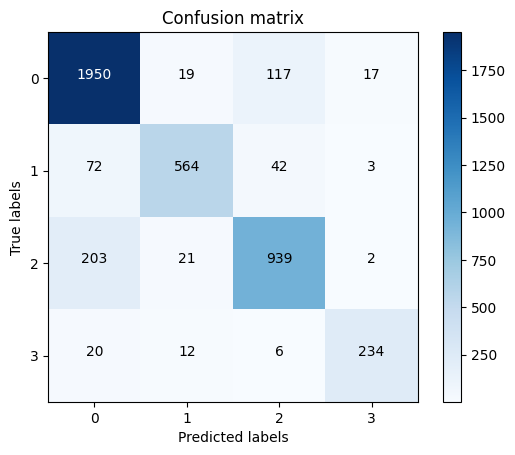

In [6]:
# Show confusion matrix
#from sklearn import metrics
#cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
#print(cnf_matrix)
import itertools

cnf_matrix = np.array([
    [1950, 19, 117, 17],
    [72, 564, 42, 3],
    [203, 21, 939, 2],
    [20, 12, 6, 234]
])

# Display a confusion matrix as a colored table
classes = range(0, 4)

plt.figure()

plt.imshow(cnf_matrix, interpolation='nearest',cmap='Blues')
plt.title("Confusion matrix")
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

for i, j in itertools.product(range(cnf_matrix.shape[0]), range(cnf_matrix.shape[1])):
    plt.text(j, i, cnf_matrix[i, j],
             horizontalalignment="center",
             color="white" if cnf_matrix[i, j] > ( cnf_matrix.max() / 2) else "black")

plt.ylabel('True labels')
plt.xlabel('Predicted labels')
plt.show()